#Brain Activity Monitoring using AI and Predictive Analysis!

This notebook implements an EEG binary classification pipeline. The raw EEG recordings are first preprocssed by selecting EEG channels, applying filtering, and segmenting the siginals into 5-secs windows. Features are then extracted to train the machine learning models, and the processed data is used to train the deep learning model (CNN) to classify normal and abnormal brain activity. After training all models are evaluated using accurcy, precision, recall, and F1-score.

## 1: NOTE!
## How to Run This Notebook

First: Update all dataset paths (Google Drive/local) to match your environment before running the code.

Option 1: Use preprocessed data (Recommended – Fast)

- Ensure the following files are available in
:
  - Processed_EEG_Dataset/
  - X_train_features.npy
  - Y_train.npy
  - X_eval_features.npy
  - Y_eval.npy

Run the following steps:
Step 1-7 run as it is (execute in second) then:  
Step 8 → Verify processed files exist  
Step 9 → Load sample file  
Step 12.3 → Load saved feature datasets  
Step 13 onwards → Train and evaluate models  

---

Option 2: Run full pipeline from raw data (Slow)

- Ensure raw EDF dataset is available in Dataset_root

Run ALL steps from:
Step 1 → Step 18

Note:
Step 7 (preprocessing) and Step 12 (feature extraction) are time-consuming and were already executed during development.



# SetUp:


*   Install + Import libraries
*   Mount drive
*   Defin dataset paths






In [ ]:
# Step 1 - install + import libraries
# IMPORTANT:
# updata the dataset paths according to your dataset path

!pip -q install mne numpy pandas scipy scikit-learn
from pathlib import Path
import numpy as np
import mne


from google.colab import drive
drive.mount('/content/drive')


#Raw dataset
Dataset_root = Path("/content/drive/MyDrive/FYP-Brain activity monitoring using AI and predictive analytics/EEG-Dataset/nmt_scalp_eeg_dataset")

# Processed dataset
Output_root = Path("/content/drive/MyDrive/FYP-Brain activity monitoring using AI and predictive analytics/EEG-Dataset/Processed_EEG_Dataset")

print("Dataset root:", Dataset_root)
print("Output root:", Output_root)

## Dataset structure verification

In [ ]:
#Step 2 Checking the folder structure

for p in [
    Dataset_root/"normal"/"train",
    Dataset_root/"normal"/"eval",
    Dataset_root/"abnormal"/"train",
    Dataset_root/"abnormal"/"eval",
]:
    # Ensure the NMT folder structure normal/abnormal are correctly mounted
    print(p, ":", "Ok" if p.exists() else "Missing")

/content/drive/MyDrive/FYP-Brain activity monitoring using AI and predictive analytics/EEG-Dataset/nmt_scalp_eeg_dataset/normal/train : Ok
/content/drive/MyDrive/FYP-Brain activity monitoring using AI and predictive analytics/EEG-Dataset/nmt_scalp_eeg_dataset/normal/eval : Ok
/content/drive/MyDrive/FYP-Brain activity monitoring using AI and predictive analytics/EEG-Dataset/nmt_scalp_eeg_dataset/abnormal/train : Ok
/content/drive/MyDrive/FYP-Brain activity monitoring using AI and predictive analytics/EEG-Dataset/nmt_scalp_eeg_dataset/abnormal/eval : Ok


## Collect EDF Files And assign lables

List edf files and labels, and label:
*   normal = 0
*   abnormal = 1




In [ ]:
#Step 3 Create a function to collect all EDF files with labels
def list_edf_files(Dataset_root: Path):
  #Create an empty list to store file information
  edf_files = []

  #Loop through the normal/abnormal classes
  for label_name, label_value in [("normal", 0), ("abnormal", 1)]:

    #Loop through both dataset splits: train and eval
    for split in ["train", "eval"]:

      #Create the full folder path
      folder = Dataset_root / label_name / split

      #Skip if the folder doesnt exit
      if not folder.exists():
        continue

      #Find all EDF files inside the folder
      for edf_path in sorted(folder.glob("*.edf")):

        #Store file path,label, split type in a dictionary
        edf_files.append({"path": edf_path, "label": label_value, "split": split})

  return edf_files

#Call the function to get all the dataset files
files = list_edf_files(Dataset_root)

#print how many EDF files were found
print("Number of EDF files:", len(files))

#print one example file to check structure
print("Example:", files[0] if files else "No files found")


Number of EDF files: 2417
Example: {'path': PosixPath('/content/drive/MyDrive/FYP-Brain activity monitoring using AI and predictive analytics/EEG-Dataset/nmt_scalp_eeg_dataset/normal/train/0000001.edf'), 'label': 0, 'split': 'train'}


## EEG Preprocessing Functions

*   Load EEG
*   Filter
*   resample
*   windowing





In [ ]:
#Step 4 - signal processing functions:
def load_raw_eeg(edf_path: Path) -> mne.io.Raw:
  #Load one EDF file as an MNE raw object
  #preload=True loads data into memory (faster processing)
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
  return raw

def simplify_channel_names(raw: mne.io.Raw) -> mne.io.Raw:
  #Make channel names consistent across files.
  #Example: "EEG Fp1-Ref" -> "Fp1"
  raw.rename_channels(lambda x: x.replace("EEG ", "").replace("-Ref", "").strip())
  return raw

def keep_eeg_only(raw: mne.io.Raw) -> mne.io.Raw:
  #keep EEG chaneels only (drop EOG/ECG/ect)
  raw.pick("eeg")
  return raw

def bandpass_filter(raw: mne.io.Raw, l_freq=1.0, h_freq=40.0) -> mne.io.Raw:
  """
  Bandpass filter:
  - remove slow drift below 1Hz
  - remove high-frequency noise above 40Hz
  """
  raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design="firwin", verbose=False)
  return raw

def window_into_epochs(raw: mne.io.Raw, window_s=5.0, overlap_s=0.0) -> mne.Epochs:
  #split continuous EEG into fixed-length windows(epochs)
  #e.g: 5-second window
  epochs = mne.make_fixed_length_epochs(raw, duration=window_s, overlap=overlap_s, preload=True, verbose=False)
  return epochs

def resample_raw(raw: mne.io.Raw, new_sfreq=200.0) -> mne.io.Raw:
  #Resample to a new sampling rate
  if raw.info["sfreq"] != new_sfreq:
    raw.resample(new_sfreq, verbose=False)
    return raw


## 5. Testing Preprocessing on one file (testing)

In [ ]:
#Step 5: Test preprocessing using first file to verify paths and labels

sample = files[0]
print("Testing on:", sample["path"].name, "label", sample["label"], "split:", sample["split"])

# Cleanup - load into RAM, fix names and drop non-EEG channels
raw = load_raw_eeg(sample["path"])
raw = simplify_channel_names(raw)
raw = keep_eeg_only(raw)

# Filtering - standard 1-40Hz range to remove drift and muscle noise
raw = bandpass_filter(raw, l_freq=1.0, h_freq=40.0)

# Windwing - slice continuous data into 5s chunks for the model
epochs = window_into_epochs(raw, window_s=5.0, overlap_s=0.0)

#export - get final NumPy array for training
X = epochs.get_data() # dimensions: windows, channels, time_steps
print("Windows/Channels/Samples:", X.shape)
print("Sampling rate:", epochs.info["sfreq"])


Testing on: 0000001.edf label 0 split: train
Windows/Channels/Samples: (40, 21, 1000)
Sampling rate: 200.0


## 6. Define Saving Function

(convert all EEG to .npy window):

X.npy (windows × channels × time)

y.npy (windows labels)

Save EDF file in a clean folder structure: processed_nmt_scalp/train/normal/xxxx_X.npy, etc.

In [ ]:
#Step 6: Setup for saving
def save_epochs_as_npy(epochs: mne.Epochs, out_x_path: Path, label: int, out_y_path: Path):
  """ This saves:
  - X: epoch data as numpy array
  - Y: label array (same length as number of epochs)
  """
  X = epochs.get_data().astype(np.float32)
  Y = np.full((X.shape[0],), label, dtype=np.int64)

  # Ensure the output directory exists, creating it and any necessary parent directories.
  out_x_path.parent.mkdir(parents=True, exist_ok=True)
  np.save(out_x_path, X)
  np.save(out_y_path, Y)

## 7. Save Preprocessed EEG data

Note!!
This step preprocesses all raw EEG files and saves them as NumPy arrays.
Due to the large dataset size and long runtime, this step was executed once and the processed files are reused in later steps bu reloading.

Saves output as:

  _X.npy -> EEG windows

  _y.npy -> labels

This step is very slow!!!
It was already executed so if files already exist this step is skipped automatically.

This can be load by going to step 10

In [ ]:
#Step 7: Run preprocessing & save files
from pathlib import Path
def save_preprocessed_eeg(edf_path: Path, label: int, split: str):
    """
    Process one EDF file and save the cleaned windows as NumPy arrays.
    Also skips if the output files already exist.(time efficient)
    steps:
    1. Load raw EEG
    2. Simplify channel names
    3. Keep only EEG channels
    4. Apply Bandpass filter 1-40Hz
    5. Break into 5-second window
    6. Save windows and labels as NumPy arrays
    """

    raw = load_raw_eeg(edf_path)
    raw = resample_raw(raw, 200.0)
    #Save into - Output_root/split(normal/abnormal)
    class_name = "normal" if label == 0 else "abnormal"
    out_dir = Output_root / split / class_name

    #Create filenames for data X and labels Y
    out_x = out_dir / f"{edf_path.stem}_X.npy"
    out_y = out_dir / f"{edf_path.stem}_Y.npy"

    #Skip if the file already exists
    if out_x.exists() and out_y.exists():
        return None  #means skipped the existing file

    raw = load_raw_eeg(edf_path)
    raw = simplify_channel_names(raw)
    raw = keep_eeg_only(raw)
    raw = bandpass_filter(raw, l_freq=1.0, h_freq=40.0)

    epochs = window_into_epochs(raw, window_s=5.0, overlap_s=0.0)

    #Save windowed EEG and corresponding labels
    save_epochs_as_npy(epochs, out_x, label, out_y)
    return epochs.get_data().shape #for logging



#Loop through all EDF files
# Process all files with basic error handeling
processed_files = 0
skipped_files = 0
failed = 0

for file in files:
  #extrat information from dictionary
  edf_path = file["path"]
  label = file["label"]
  split = file["split"]

  try:
    #Run preprocessing for one file
    shape = save_preprocessed_eeg(edf_path, label, split)

    # Corrected logic for skipped vs processed files
    if shape is None:
      skipped_files += 1
    else:
      processed_files += 1

    #print progress every 10 files
    if (processed_files + skipped_files) % 50 == 0:
      print(f"Processed {processed_files+skipped_files}/{len(files)} "
            f"(processed={processed_files}, skipped={skipped_files}, failed={failed})")

  except Exception as e:
    #If something fails, increase failed counter
    failed += 1
    print(f"Failed: {edf_path.name} -> {e}")


print("Done.")
print("Processed:", processed_files, "skipped:", skipped_files, "Failed", failed)

if processed_files == 0:
  print("Processed files already exist. Skipping preprocessing")
print("Saved to:", Output_root)

Failed: 0000001.edf -> cannot access local variable 'raw' where it is not associated with a value
Failed: 0000003.edf -> cannot access local variable 'raw' where it is not associated with a value
Failed: 0000005.edf -> cannot access local variable 'raw' where it is not associated with a value
Failed: 0000006.edf -> cannot access local variable 'raw' where it is not associated with a value
Failed: 0000007.edf -> cannot access local variable 'raw' where it is not associated with a value
Failed: 0000011.edf -> cannot access local variable 'raw' where it is not associated with a value
Failed: 0000013.edf -> cannot access local variable 'raw' where it is not associated with a value
Failed: 0000014.edf -> cannot access local variable 'raw' where it is not associated with a value
Failed: 0000016.edf -> cannot access local variable 'raw' where it is not associated with a value
Failed: 0000020.edf -> cannot access local variable 'raw' where it is not associated with a value
Failed: 0000021.edf 

## 8. Load processed EEG dataset:

*   Total Train/eval -> normal
*   Total Test/eval -> normal



In [ ]:
#step 8
# Collects all the preprocessed EEG data files (.npy) for both training and evaluation sets,
# separating them by 'normal' and 'abnormal' categories, and then prints the count for each category.
train_normal = list((Output_root/"train"/"normal").glob("*_X.npy"))
train_abnormal = list((Output_root/"train"/"abnormal").glob("*_X.npy"))

eval_normal = list((Output_root/"eval"/"normal").glob("*_X.npy"))
eval_abnormal = list((Output_root/"eval"/"abnormal").glob("*_X.npy"))

print("Train normal:", len(train_normal))
print("Train abnormal:", len(train_abnormal))
print("Eval normal:", len(eval_normal))
print("Eval abnormal:", len(eval_abnormal))

Train normal: 1875
Train abnormal: 355
Eval normal: 95
Eval abnormal: 90


## 9. Load a sample Preprocessed EEG to verify it worked correctly

In [ ]:
#Step 9: Load a sample preprocessed EEG data file to check its shape.

from pathlib import Path
import numpy as np

sample_file = list((Output_root / "train" / "normal").glob("*_X.npy"))[0]

X = np.load(sample_file)
print("Shape:", X.shape)

Shape: (120, 21, 1000)


## Looping through the saved .npy files one-by-one

In [ ]:
# step 10: Memory-Efficent data loading

def iter_processed_files(split_name: str):
    """
    Loop through saved .npy files one by one (prevents RAM crash).
    Yields:
      X: EEG windows, shape (windows, channels, time_samples)
      Y: labels, shape (windows,)
    """
    split_path = Output_root / split_name

    #Loop through normal & abnormal
    for class_name in ["normal", "abnormal"]:
      class_folder = split_path / class_name

      #Loop through every saved EEG window file
      for x_file in sorted(class_folder.glob("*_X.npy")):

         #Find the matching label file
          y_file = class_folder / x_file.name.replace("_X.npy", "_Y.npy")

          try:

            X = np.load(x_file) # Windowed EEG
            Y = np.load(y_file) #Labels for each window

            yield X, Y

          except Exception as e:
            print(f"Skipping corrupted file: {x_file.name} -> {e}")


## 11. Feature Extraction (Bandpower Features)

In [ ]:
#Step 11: Feature extraction(bandpower) used for machine learning models
import numpy as np
from scipy.signal import welch

def bandpower_features_one_window(window_data: np.ndarray, sfreq: int) -> np.ndarray:
  """
  Convert one EEG window into bandpower features.
  window_data shape: (channels, time_samples)
  return 1D feature vector (channels x bands)
  """

  bands = {
      "delta": (1, 4),
      "theta": (4, 8),
      "alpha": (8, 13),
      "beta": (13, 30),
      "gamma": (30, 40)
  }

  features = []

  #Process each EEG channel separately
  for chaneel_signal in window_data:
    freqs, psd = welch(chaneel_signal, fs=sfreq, nperseg=256)

    #Add average power for each band
    for (low, high) in bands.values():
      idx = (freqs >=low) & (freqs <= high)
      features.append(psd[idx].mean())

  return np.array(features, dtype=np.float32)


def bandpower_features_for_file(X_file: np.ndarray, sfreq: int) -> np.ndarray:

  """
  Convert all eeg window from saved file into bandpower features.
  X_file shape: (windows, channels, time_samples)
  return (windows x features)
  """
  return np.vstack([bandpower_features_one_window(win, sfreq) for win in X_file])

## 12. Build full feature matrices for train & eval
This step converts saved EEG windows (.npy files) into final feature matrices that can be used for Machine Learning models.

 Extracts features for all files.

 Build full ML dataset

 Output:

    X_train_features.npy

    Y_train.npy

    X_eval_features.npy

    Y_eval.npy

IMPORTANT:
Already executed and saved for easy/fast reload and useable

In [ ]:
# # #Step 12: Build full feature matrices for train & eval

# sfreq = 200

# def build_feature_dataset(split_name: str):
#   """
#   Builds full feature dataset for a given split (train or eval).
#   1. Loops through all saved windowed EEG files.
#   2. Extract bandpower features for each window.
#   3. Combines all windown into one large feature matrix
#   """

#   X_feature_list = []   #Store extracted features for each file
#   Y_list = []           #Store labels for each file
#   file_count = 0        #Counter for processed files

#   #Define path to either train or eval folder
#   split_path = Output_root / split_name
#   print("Processing split:", split_path)

#   #Loop through normal & abnormal
#   for class_name in ["normal", "abnormal"]:
#     class_folder = split_path / class_name

#     if not class_folder.exists():
#       print(f"Warning: Class folder '{class_folder}' does not exist")
#       continue

#     #Loop through every saved EEG window file
#     for x_file in sorted(class_folder.glob("*_X.npy")):

#       #Find the matching label file
#       y_file = class_folder / x_file.name.replace("_X.npy", "_Y.npy")

#       try:
#         #load one file at a time
#         x_data = np.load(x_file)    # Windowed EEG
#         y_data = np.load(y_file)    #Labels for each window

#         #Convert raw windiwed EEG into bandpower feature vectors
#         x_feats = bandpower_features_for_file(x_data, sfreq)

#         #Store features and labesl
#         X_feature_list.append(x_feats)
#         Y_list.append(y_data)

#         file_count += 1

#         #Print progress every 50 files
#         if file_count % 50 == 0:
#           total_windows = sum(arr.shape[0] for arr in Y_list)
#           print(f"{split_name}: Processed {file_count} files | windows: {total_windows}")

#       except Exception as e:
#         # Skip corrupted or unreadable files
#         print("Skipping:", x_file.name)

#   #Combine all features array into one matrix
#   X_features = np.vstack(X_feature_list)
#   Y_all = np.concatenate(Y_list)

#   return X_features, Y_all

# #Build training feature matrix
# print("Building train features:")
# X_train_features, Y_train = build_feature_dataset("train")

# #Build evaluation feature martix
# print("Building eval features:")
# X_eval_features, Y_eval = build_feature_dataset("eval")

# #Finally print dataset shapes
# print("Train features:", X_train_features.shape)
# print("Eval features:", X_eval_features.shape)

In [ ]:
# step 12.1
# #This saves step 12 so no need to run it again since it takes almost 2hours.

# project_folder = "/content/drive/MyDrive/FYP-Brain activity monitoring using AI and predictive analytics/EEG-Dataset"

# np.save(f"{project_folder}/X_train_features.npy", X_train_features)
# np.save(f"{project_folder}/Y_train.npy", Y_train)
# np.save(f"{project_folder}/X_eval_features.npy", X_eval_features)
# np.save(f"{project_folder}/Y_eval.npy", Y_eval)

In [ ]:
# step 12.2
#Upload it to drive

# project_folder = "/content/drive/MyDrive/FYP-Brain activity monitoring using AI and predictive analytics/EEG-Dataset"

# !cp *.npy "$project_folder"

In [ ]:
# Step 12.3 Feature dataset saved for faster execution

# This step allows u to skip step 12 and just execute this
# X_train_features.npy -> training feature matrix (powerpower features)
# Y_train.npy -> training label 0 or 1
# X_eval_features.npy -> evaluation feature matrix
# y_eval_features.npy -> evaluation labels


base = "/content/drive/MyDrive/FYP-Brain activity monitoring using AI and predictive analytics/EEG-Dataset"

X_train_features = np.load(f"{base}/X_train_features.npy")
Y_train = np.load(f"{base}/Y_train.npy")
X_eval_features = np.load(f"{base}/X_eval_features.npy")
Y_eval = np.load(f"{base}/Y_eval.npy")

## 13. Train Logistic Regression baseline model

This serves as a Machine Learning baseline for comparison.

*   Feature extraction
*   Large feature matrices
*   Logistic Regression baseline
*   Proper scaling
*   Class imbalance handling

In [ ]:
#Step 13:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

#Feature scaling
#Standardlisation improve performance for linear models by ensuring all #features have mean=0 and variance=1

scaler = StandardScaler()

#Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train_features)

#Use same scaler parameters for evaluation data
X_eval_scaled = scaler.transform(X_eval_features)

# Model definition
#class_weight="balanced" helps handle class imbalance
# max_iter increated to ensure convergence
model = LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1)

#Train model using scaled training features
model.fit(X_train_scaled, Y_train)

#predict on evaluation set
Y_pred = model.predict(X_eval_scaled)

#Evaluation metrics
# Accuracy: overall correctness
#Confuion matrix: class-wise performance
#Classififcation report: precision, recall, F1-score

print("Accuracy:", accuracy_score(Y_eval, Y_pred))
print("\nConfustion matrix:\n", confusion_matrix(Y_eval, Y_pred))
print("\nClassification report:\n", classification_report(Y_eval, Y_pred, digits=3))

Accuracy: 0.6519194222729

Confustion matrix:
 [[10907  2477]
 [ 6681  6245]]

Classification report:
               precision    recall  f1-score   support

           0      0.620     0.815     0.704     13384
           1      0.716     0.483     0.577     12926

    accuracy                          0.652     26310
   macro avg      0.668     0.649     0.641     26310
weighted avg      0.667     0.652     0.642     26310



A bandpower-based Logistic Regression model was used as a baseline before applying deep learning.


## Support Vector Machine(Stronger ML Baseline)

In [ ]:
#Step 14 Train SVM Baseline
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier

# Define SVM model
# kernell="rbf" allows non linear decision boundary

svm_model = SGDClassifier(
    loss="hinge",
    class_weight="balanced", # handle class imbalance
    max_iter=5000,
    tol=1e-3,
    random_state=42,
    n_jobs=-1
)

print("Training SVM model...")
svm_model.fit(X_train_scaled, Y_train)

# perdict on evaluation data
Y_pred_svm = svm_model.predict(X_eval_scaled)

#Evaluation Performance
print("Accuracy:", accuracy_score(Y_eval, Y_pred_svm))
print("\nConfustion matrix:\n", confusion_matrix(Y_eval, Y_pred_svm))
print("\nClassification report:\n", classification_report(Y_eval, Y_pred_svm, digits=3))

Training SVM model...
Accuracy: 0.6463321930824781

Confustion matrix:
 [[11495  1889]
 [ 7416  5510]]

Classification report:
               precision    recall  f1-score   support

           0      0.608     0.859     0.712     13384
           1      0.745     0.426     0.542     12926

    accuracy                          0.646     26310
   macro avg      0.676     0.643     0.627     26310
weighted avg      0.675     0.646     0.629     26310



## 15. Random Forest Model

In [ ]:
# Step 15

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import pandas as pd

print("Training Random Forest Model...")

random_forest_model = RandomForestClassifier(
    n_estimators= 400,    #number of trees - reduce it in future running as it takes long to run
    max_depth=20,         #max depth of each tree
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,

)

random_forest_model.fit(X_train_features, Y_train)

Y_pred_random_forest = random_forest_model.predict(X_eval_features)

print("Accuracy:", accuracy_score(Y_eval, Y_pred_random_forest))
print("\nConfustion matrix:\n", confusion_matrix(Y_eval, Y_pred_random_forest))
print("\nClassification report:\n", classification_report(Y_eval, Y_pred_random_forest, digits=3))

print(np.bincount(Y_train))

#Feature importance analysis
feature_importance_scores = random_forest_model.feature_importances_
feature_df = pd.DataFrame({
    "feature": range(len(feature_importance_scores)),
    "importance": feature_importance_scores
}).sort_values(by="importance", ascending=False)

print(feature_df.head(10))

Training Random Forest Model...
Accuracy: 0.6874952489547701

Confustion matrix:
 [[12428   956]
 [ 7266  5660]]

Classification report:
               precision    recall  f1-score   support

           0      0.631     0.929     0.751     13384
           1      0.856     0.438     0.579     12926

    accuracy                          0.687     26310
   macro avg      0.743     0.683     0.665     26310
weighted avg      0.741     0.687     0.667     26310

[271474  53388]
     feature  importance
96        96    0.028722
101      101    0.028351
26        26    0.024349
66        66    0.019837
81        81    0.019430
25        25    0.019343
98        98    0.018808
103      103    0.016842
16        16    0.016555
86        86    0.016118


 ## XGBoost Gradient Boosting Model

In [ ]:
# Step 16:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Training XGBoost Model...")

#define XGBoost model
# Scalp_pos_weight helps handle class imbalance
xgboost_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=5,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
)

# Train model
xgboost_model.fit(X_train_features, Y_train)

# predict probabilities for evaluation data
Y_probs = xgboost_model.predict_proba(X_eval_features)[:, 1]

# Adjust classification threshold (Default = 0.5)
threshold = 0.4
Y_pred_xgboost = (Y_probs > threshold).astype(int)

# Evaluation performance
print("Accuracy:", accuracy_score(Y_eval, Y_pred_xgboost))
print("\nConfusion matrix:\n", confusion_matrix(Y_eval, Y_pred_xgboost))
print("\nClassification report:\n", classification_report(Y_eval, Y_pred_xgboost, digits=3))

Training XGBoost Model...
Accuracy: 0.7407069555302166

Confusion matrix:
 [[ 9414  3970]
 [ 2852 10074]]

Classification report:
               precision    recall  f1-score   support

           0      0.767     0.703     0.734     13384
           1      0.717     0.779     0.747     12926

    accuracy                          0.741     26310
   macro avg      0.742     0.741     0.741     26310
weighted avg      0.743     0.741     0.740     26310



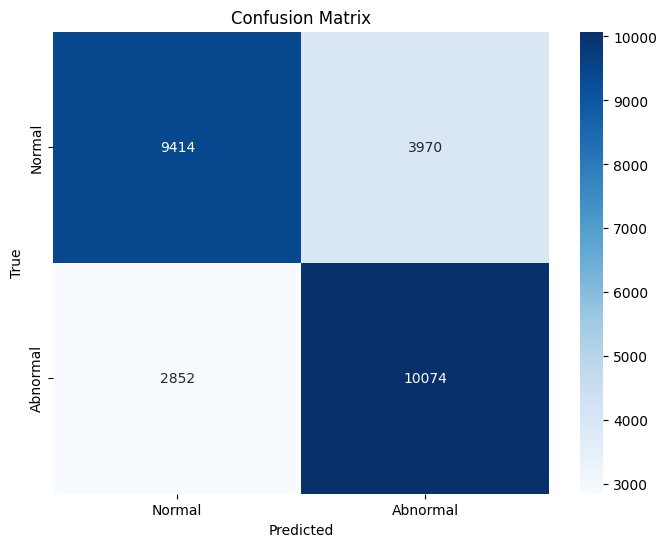

In [ ]:
# 16.1 XGBoost Confusion matric
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(Y_eval, Y_pred_xgboost)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Deep Learning Setup -> Install PyTorch

In [ ]:
#step 17.1
!pip install torch torchvision torchaudio -q

## Import Libraries

In [ ]:
#Step 17.2
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Load Raw EEG window

In [ ]:
# Step 17.3 Loading Raw EEG windows

dataset_path = "/content/drive/MyDrive/FYP-Brain activity monitoring using AI and predictive analytics/EEG-Dataset/Processed_EEG_Dataset"

#loading subset of the dataset 80000 samples
def load_subset(split, max_windows=80000):

    X_list = [] #list to hold EEG signal data
    Y_list = [] # list to hold corresponding labels 0=normal, 1=abnormal

    # Ensure equal representation by loading the same number of sample for each class
    per_class = max_windows // 2
    split_path = Path(dataset_path) / split

    # Iterate through normal & abnormal folders to collect data
    for label, class_name in enumerate(["normal","abnormal"]):
        folder = split_path / class_name
        count = 0

        #Look for all .npy files containing the EEG feature data
        for x_file in folder.glob("*_X.npy"):

            # Find the matching label file for the current data file
            y_file = folder / x_file.name.replace("_X.npy","_Y.npy")

            # Load binary numpy arrays from disk
            X = np.load(x_file)
            Y = np.load(y_file)

            # Extract individual windows from the file and append to main list
            for i in range(len(X)):
                X_list.append(X[i])
                Y_list.append(Y[i])

                count += 1

                # Stop loading once reached the limit for this specific class
                if count >= per_class:
                  break

            if count >= per_class:
                  break

    #Convert lists to numpy arrays from compatibility with machine learning models
    return np.array(X_list), np.array(Y_list)

print("Loading training data...")
X_train, Y_train = load_subset("train", 80000)

print("Loading evaluation data...")
X_eval, Y_eval = load_subset("eval", 20000)

print("Train shape:", X_train.shape)
print("Eval shape:", X_eval.shape)

Loading training data...
Loading evaluation data...
Train shape: (80000, 21, 1000)
Eval shape: (20000, 21, 1000)


In [ ]:
# Normalize each EEG channel
mean = X_train.mean(axis=(0,2), keepdims=True)
std = X_train.std(axis=(0,2), keepdims=True)

X_train = (X_train - mean) / (std + 1e-8)
X_eval = (X_eval - mean) / (std + 1e-8)

## Convert data to PyTorch tensors for neural network training

In [ ]:
#Step 17.4 convert to pytorch tensors
# Convert features to 32 bits floats so the model can perform decimal math
X_train = torch.tensor(X_train, dtype=torch.float32)

# Convert labels to long int because they represent class of 0 or 1
Y_train = torch.tensor(Y_train, dtype=torch.long)

X_eval = torch.tensor(X_eval, dtype=torch.float32)
Y_eval = torch.tensor(Y_eval, dtype=torch.long)

## DataLoaders

In [ ]:
# step 17.5: Create DataLoaders
# combine training features and labels into a dataset then split into batches of 64
train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=64,
    shuffle=True # this ensures the model doesnt learn the order of the data
)

# prepare  the evaluation dataset in batches for efficient memory usage
eval_loader = DataLoader(
    TensorDataset(X_eval, Y_eval),
    batch_size=64
)

## Defining CNN Model


In [ ]:
# Step 17.6: CNN model
import torch
import torch.nn as nn
import torch.nn.functional as F

class EEG_CNN(nn.Module):

  def __init__(self, num_classes=2):
    super(EEG_CNN, self).__init__()

    # 1st Convolution layer - extracts basic spatial patterns from EEG data
    self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)

    # Normalise the data to keep training stable & prevent exploding gradients
    self.bn1 = nn.BatchNorm2d(32)

    #2ed convolution - capture more complex features
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    # 2ed normalisation layer for deeper features
    self.bn2 = nn.BatchNorm2d(64)

    # 3rd conv- for deeper feature extraction
    self.conv3 = nn.Conv2d(64,128, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(128)

    # pooling layer - reduce size & computation
    self.pool = nn.MaxPool2d(2,2)

    #dropout - reduces overfitting
    self.dropout1 = nn.Dropout(0.3)
    self.dropout2 = nn.Dropout(0.5)

    # Adaptive pooling - avoid manual size calculation
    self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

    # fully connected layers
    self.fc1 = nn.Linear(128, 64)
    self.fc2 = nn.Linear(64, num_classes)

  def forward(self, x):
    # if input is 3D (channels, time), add channel dimension
    if x.dim() == 3:
      x = x.unsqueeze(1)

    # Forward pass
    # black 1- conv -> batchnorm -> relu -> pooling
    x = self.pool(F.relu(self.bn1(self.conv1(x))))

    # block 2
    x = self.pool(F.relu(self.bn2(self.conv2(x))))

    # apply dropout to reduce overfitting
    x = self.dropout1(x)

    #block 3
    x = F.relu(self.bn3(self.conv3(x)))

    # Global pooling -> output becomes (batch, 128, 1, 1)
    x = self.global_pool(x)

    # flatten into vector for fully connected layers
    x = torch.flatten(x,1)

    #fully connected layers
    x = F.relu(self.fc1(x))
    x = self.dropout2(x)

    # finnal Output (class scores)
    x = self.fc2(x)

    return x

# create a model
model = EEG_CNN()
print(model)

EEG_CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.3, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)


## Training setup

In [ ]:
# step 17.6 Training setup
#Check if GPU(cuda) is available if not use to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the model's weights and calculations t the selected device
model = model.to(device)

# Define the Loss Function- measures the error between predictions & true labels
criterion = nn.CrossEntropyLoss()

# Define the Optimiser- the algorithm that updates model weights to reduce the error
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

## Training CNN

In [ ]:
# Step 17.7 Train CNN

epochs = 40 # number of times the model will see the entire dataset

# Ensure the model is on the correct device before starting the training loop
model = model.to(device)

train_losses = [] # List to track training loss
val_losses = []   # List to track validation loss

for epoch in range(epochs):

  model.train() # set the model to training mode- activities Dropout & BatchNorm
  total_loss = 0

  for x_batch, y_batch in train_loader:

    # move the current batch down to the GPU if available or CPU
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

    #Clear previous gradients so they dont accumulate & mess up the updata
    optimizer.zero_grad()

    # Perform the 'Forward Pass' pass data through the model to get predictions
    outputs= model(x_batch)

    # calculate the error by comparing model predictions to the actual labels
    loss = criterion(outputs, y_batch)

    # Backward Pass- Calculate the gradients (the direction to adjust the weights
    loss.backward()

    #Update model weights based on the gradients to reduce future error
    optimizer.step()

    #Sum up the loss value to track progress for the current epoch
    total_loss += loss.item()

  avg_loss = total_loss/len(train_loader)
  train_losses.append(avg_loss)

  # Validation Phase
  model.eval() # Set model to evaluation mode
  total_val_loss = 0
  with torch.no_grad():
    for x_val, y_val in eval_loader:
      x_val, y_val = x_val.to(device), y_val.to(device)

      # Remove unsqueeze(1) for Conv1d model
      val_outputs = model(x_val)

      val_loss = criterion(val_outputs, y_val)
      total_val_loss += val_loss.item()

  avg_val_loss = total_val_loss / len(eval_loader)
  val_losses.append(avg_val_loss)

  #print the average loss for this epoch to monitor the learning progress
  print(f"Epoch {epoch+1} Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch 1 Loss: 0.4665 | Val Loss: 0.7205
Epoch 2 Loss: 0.4600 | Val Loss: 0.6346
Epoch 3 Loss: 0.4551 | Val Loss: 0.6466
Epoch 4 Loss: 0.4477 | Val Loss: 0.5946
Epoch 5 Loss: 0.4427 | Val Loss: 0.6616
Epoch 6 Loss: 0.4363 | Val Loss: 0.7754
Epoch 7 Loss: 0.4319 | Val Loss: 0.7568
Epoch 8 Loss: 0.4277 | Val Loss: 0.6638
Epoch 9 Loss: 0.4255 | Val Loss: 0.6494
Epoch 10 Loss: 0.4205 | Val Loss: 0.5653
Epoch 11 Loss: 0.4158 | Val Loss: 0.6574
Epoch 12 Loss: 0.4135 | Val Loss: 0.8835
Epoch 13 Loss: 0.4077 | Val Loss: 0.6318
Epoch 14 Loss: 0.4049 | Val Loss: 0.7459
Epoch 15 Loss: 0.4004 | Val Loss: 0.7649
Epoch 16 Loss: 0.3982 | Val Loss: 0.7235
Epoch 17 Loss: 0.3955 | Val Loss: 0.7781
Epoch 18 Loss: 0.3920 | Val Loss: 0.6664
Epoch 19 Loss: 0.3882 | Val Loss: 0.7144
Epoch 20 Loss: 0.3855 | Val Loss: 0.7381
Epoch 21 Loss: 0.3807 | Val Loss: 0.6719
Epoch 22 Loss: 0.3800 | Val Loss: 0.7550
Epoch 23 Loss: 0.3785 | Val Loss: 0.6819
Epoch 24 Loss: 0.3732 | Val Loss: 0.6589
Epoch 25 Loss: 0.3721 | V

## CNN Evaluation

In [ ]:
# Step 17.8 Evaluate CNN
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model.eval() # Set model to evaluation

# lists to store model's guesses & actual labels for comparison
all_predictions = []
all_labels = []

# Disable gradient calculations to save memory & spped up the process since we aren't training
with torch.no_grad():
  for x_batch, y_batch in eval_loader:

    #Move the test batch to the GPU/CPU device
    x_batch = x_batch.to(device)

    # Run the forward pass to get the model's raw scores (unsqueeze is now handled inside 2D models)
    outputs = model(x_batch)

    #convert raw scores to class labels 0 or 1 by picking the highest logits
    predictions = torch.argmax(outputs, axis=1).cpu().numpy()

    # save all predictions and actual labels for the final report
    all_predictions.extend(predictions)
    all_labels.extend(y_batch.numpy())

print("Accuracy:", accuracy_score(all_labels, all_predictions))

print("\nClassification Report:")
print(classification_report(all_labels, all_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_predictions))


Accuracy: 0.68555

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.67      0.68     10000
           1       0.68      0.70      0.69     10000

    accuracy                           0.69     20000
   macro avg       0.69      0.69      0.69     20000
weighted avg       0.69      0.69      0.69     20000


Confusion Matrix:
[[6719 3281]
 [3008 6992]]


## CNN Confusion Matrix

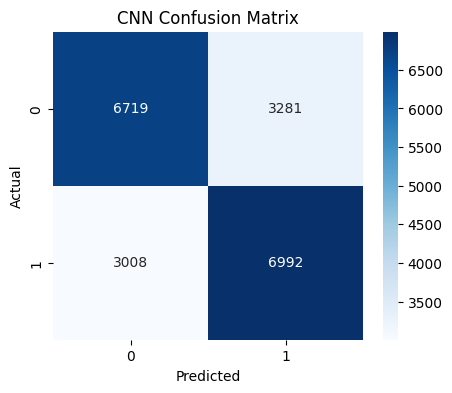

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Calculate confusion matrix

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

## Class Imbalance distribution

In [ ]:
print("Train Normal:", np.sum(Y_train.numpy() == 0))
print("Train Abnormal:", np.sum(Y_train.numpy() == 1))

print("Eval Normal:", np.sum(Y_eval.numpy() == 0))
print("Eval Abnormal:", np.sum(Y_eval.numpy() == 1))

Train Normal: 40000
Train Abnormal: 40000
Eval Normal: 10000
Eval Abnormal: 10000


## Training and Validation Loss Curve

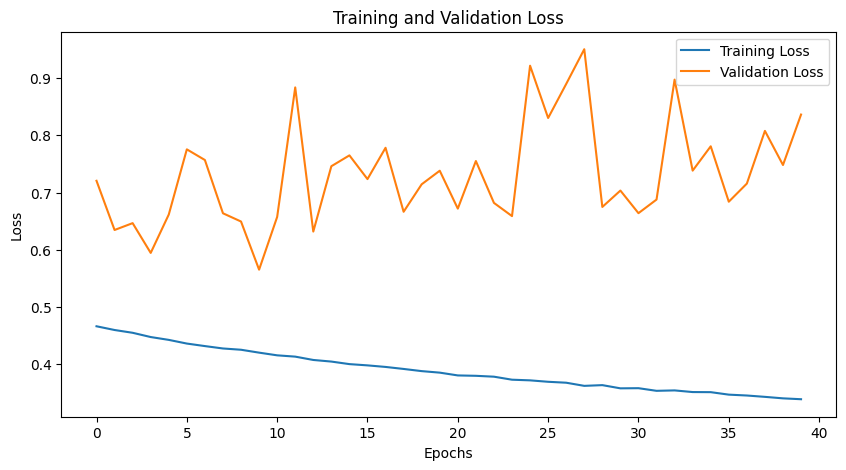

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

## Generate a Saliency Heatmap (Explainable AI)

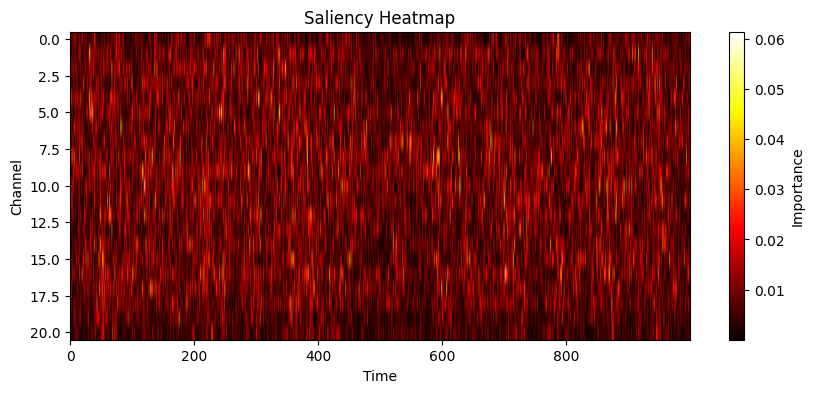

In [ ]:
# Step 18: Saliency heatmap
# This helps visualize which EEG channels and time points influenced the model's decision most
import matplotlib.pyplot as plt

# Set model to evaluation mode to ensure dropout/batchnorm dont interface with gradients
model.eval()

def get_saliency_map(sample):
  # Add a batch dimension & move the single EEG sample to the GPU/CPU
  sample = sample.unsqueeze(0).to(device)
  sample.requires_grad = True

  # Get model's prediction fro this specific sample
  output = model(sample)
  pred_class = output.argmax().item()

  #Clear any old gradients and perform a backward pass based on the predicted class
  model.zero_grad()
  output[0, pred_class].backward()

  # # The saliency is the absolute value of the gradient, higher values mean more importance
  saliency = sample.grad.abs().cpu().detach().numpy()[0]
  return saliency

#Compute the importance map for the 1st sample in our evaluation
saliency = get_saliency_map(X_eval[0])

#Plot heatmap
plt.figure(figsize=(10, 4))
# "hot" colourmap shows high importance areas in yellow/while & low in dark-red/balck
plt.imshow(saliency, aspect="auto", cmap="hot")
plt.colorbar(label="Importance")
plt.xlabel("Time")
plt.ylabel("Channel")
plt.title("Saliency Heatmap")
plt.show()

## Visualize Saliency Scalp Maps (Topographical Importance)

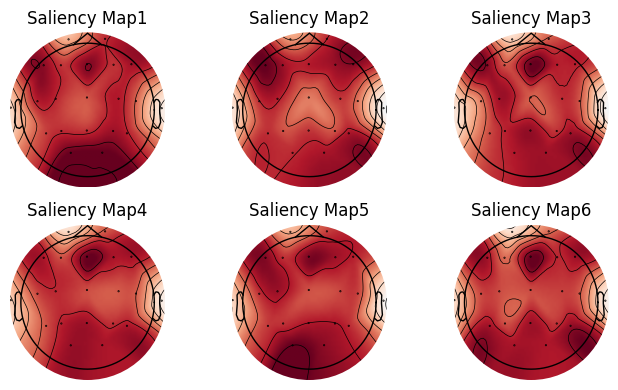

In [ ]:
# Step 18.1: Saliency scalp maps

# Re-load and preprocess a single raw EEG file to get the 'info' object for topomap
# This assumes 'sample', 'load_raw_eeg', 'simplify_channel_names', and 'keep_eeg_only' are available from previous cells.
import mne.channels
import matplotlib.pyplot as plt

raw_for_info = load_raw_eeg(sample["path"])
raw_for_info = simplify_channel_names(raw_for_info)
raw_for_info = keep_eeg_only(raw_for_info)

# Before applying montage, ensure channel names match 10-20 standard casing
channel_rename_map = {
    'FP1': 'Fp1', 'FP2': 'Fp2',
    'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz'
}
raw_for_info.rename_channels(channel_rename_map)

# Apply a standard 10-20 montage to get electrode locations
montage = mne.channels.make_standard_montage('standard_1020')
raw_for_info.set_montage(montage, on_missing='ignore')

info = raw_for_info.info # Extract the info object

# Create a 2x3 grid to visualize the saliency for the first 6 samples in the evaluation set
fig, axes = plt.subplots(2, 3, figsize=(7, 4))

for i, ax in enumerate(axes.flatten()):
  #Extract the saliency map for the current sample using XAI function
  saliency = get_saliency_map(X_eval[i])

  #Convert to channel importance
  channel_importance = saliency.mean(axis=1)
  #Normalise the importance score between 0 & 1 for consistent color scaling
  channel_importance = channel_importance / channel_importance.max()

  # Use the MNE library to project the 21 channel scores onto a 2D scalp map
  mne.viz.plot_topomap(
      channel_importance,
      info,   #This variable contains our EEG electrode layout (10-20 system)
      axes=ax,  #don't show yet, we want to finish the whole grid first
      show=False,
      cmap="RdBu_r"
  )
  ax.set_title(f"Saliency Map{i+1}")
plt.title("Saliency Scalp Maps")# check if it overlap
plt.tight_layout()
plt.show()

## Bar-Chart: Comparison Between Models

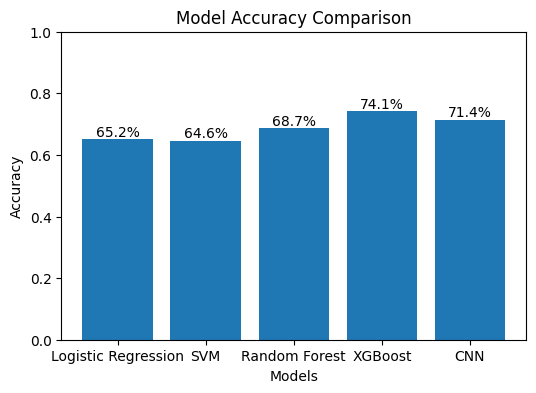

In [ ]:
# Step 18.2: Model comparison
models = ["Logistic Regression", "SVM", "Random Forest", "XGBoost", "CNN"]
# Update accuracy values based on the actual output from previous steps
accuracy = [0.652, 0.646, 0.687, 0.741, 0.714]

plt.figure(figsize=(6,4))
bars = plt.bar(models, accuracy)

#add percentage for clear visual
for bar, acc in zip(bars, accuracy):
  plt.text(
      bar.get_x() + bar.get_width()/2,
      bar.get_height(),
      f"{acc*100:.1f}%",
      ha='center', va='bottom'
  )


plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()